# Notebook 02:  Bias & Fairness Analysis

This notebook performs a bias and fairness analysis to the clean dataset, after the remediation steps in the previous notebooks were done (`cleaned_dataset.json`).  

The objective is to:
- Identify potential bias in historical decisions
- Find supporting/refuting statistical evidence of that bias  
- Perform proxy discrimination analysis
- Explore potential interaction effects 
- Provide visualization of findings


This notebook is structured as follows:

1. Gender Bias Patterns
2. Age Bias Patterns
3. Interaction Analysis
4. Proxy Discrimination Analysis
5. Bias & Fairness Analysis Summary

### AI Assistance Acknowledgment

The development of this analytical notebook was supported by Google's Gemini. The AI assistant was utilized strictly for code optimization, syntax debugging (such as resolving `pandas` categorical errors), and refining the structural clarity of the markdown narratives. All methodological design, statistical testing decisions, and final governance conclusions remain the exclusive, original work of the project team, in accordance with academic guidelines.

## 0. Environment Setup & Data Ingestion

Before initiating the algorithmic bias evaluation, we must import the requisite data manipulation and numerical analysis libraries (`pandas` and `numpy`). Subsequently, we will load the pre-processed JSON dataset finalized during the data quality assessment phase to ensure our fairness metrics are calculated on structurally validated data.

In [174]:
# Imports and loading the dataset
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fairlearn.metrics import demographic_parity_ratio
from scipy.stats import chi2_contingency, chi2

# Load the JSON 
df = pd.read_json("../data/cleaned_dataset.json")

# Convert the DataFrame into a flat list of row dictionaries
records = df.to_dict(orient='records')

# Now flatten the nested dictionaries
df_clean = pd.json_normalize(records)

# Filter to only include rows where dq_action is "ok"
df_clean = df_clean[df_clean["dq_action"] == "ok"]
df_clean.reset_index(drop=True, inplace=True)

# Sanity check
print("Columns in the cleaned DataFrame:")
print(df_clean.columns.tolist())



Columns in the cleaned DataFrame:
['_id', 'spending_behavior', 'processing_timestamp', 'loan_purpose', 'notes', 'applicant_info.date_of_birth_clean', 'dq_flag_duplicate_note', 'dq_flag_duplicate_ssn', 'dq_flag_duplicate_email', 'dq_duplicate_any', 'dq_action', 'dq_flag_future_processing_ts', 'applicant_info.full_name', 'applicant_info.email', 'applicant_info.ssn', 'applicant_info.ip_address', 'applicant_info.gender', 'applicant_info.date_of_birth', 'applicant_info.zip_code', 'applicant_info.gender_clean', 'financials.annual_income', 'financials.credit_history_months', 'financials.debt_to_income', 'financials.savings_balance', 'financials.annual_salary', 'financials.annual_income_clean', 'decision.loan_approved', 'decision.rejection_reason', 'decision.interest_rate', 'decision.approved_amount']


## Assessing Bias

We assess demographic parity and potential bias primarily through the **Disparate Impact (DI) Ratio**. The formula is:

$$DI = \frac{\text{Approval Rate of Unprivileged Group}}{\text{Approval Rate of Privileged Group}}$$

The **Four-Fifths Rule** serves as an industry-standard threshold. It states that if one group's approval rate is less than 80% ($DI < 0.8$) of the privileged group's rate, it flags potential adverse impact against the unprivileged group. This serves as a trigger to rigorously investigate for potential discrimination.



#### Statistical Testing for Disparities
To investigate the flagged disparity, we conduct a two-sample hypothesis test at a 5% significance level ($\alpha = 0.05$) to determine if the difference in approval rates (or means) is statistically significant. 

* **$H_0: \mu_1 - \mu_2 = 0$** (There is no difference between the groups' true means)
* **$H_1: \mu_1 - \mu_2 \neq 0$** (There is a statistically significant difference between the groups)

The test statistic is calculated using the sample means ($\bar{x}$), sample variances ($s^2$), and sample sizes ($n$):

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

*Note: For large sample sizes ($n > 30$), the t-distribution approaches the standard normal (Z) distribution, making the critical value approximately **1.96** for a two-tailed test at $\alpha = 0.05$.*

#### Conclusion Criteria
* **If $|t| > 1.96$**: We **reject the null hypothesis**. There is statistically significant evidence supporting a disparity in outcomes between the groups.
* **If $|t| \le 1.96$**: We **fail to reject the null hypothesis**. There is insufficient statistical evidence to confirm a disparity exists.

**Important Note:** It is standard practice to prioritize statistical testing if the DI flags potential bias ($DI < 0.8$). However, a $DI \ge 0.8$ does not mathematically guarantee the complete absence of discrimination; it simply means the disparity does not cross the standard regulatory threshold for *prima facie* adverse impact.

## 1. Gender Bias Patterns

In this section, we evaluate NovaCred's historical credit outcomes to detect potential gender-based algorithmic bias. We apply the previously established methodological framework (calculating the Disparate Impact Ratio and conducting rigorous hypothesis testing) to determine if statistically significant disparities exist between privileged and unprivileged gender groups.

## 1.1 Loan Approval

In [175]:
# Gender bias analysis using Fairlearn's demographic parity ratio
gender_DI = demographic_parity_ratio(
    y_true=df_clean['decision.loan_approved'], 
    y_pred=df_clean['decision.loan_approved'], 
    sensitive_features=df_clean['applicant_info.gender_clean']
)

print(f"Fairlearn DI Ratio (Gender): {gender_DI:.2f}")

# To confirm it's female bias
print("\nLoan approval rates by gender:")
approved_by_gender = df_clean.groupby("applicant_info.gender_clean", observed=True)["decision.loan_approved"]
print(approved_by_gender.mean())

print("\nWarning: Potential bias detected against females.")

Fairlearn DI Ratio (Gender): 0.77

Loan approval rates by gender:
applicant_info.gender_clean
female    0.508130
male      0.662551
Name: decision.loan_approved, dtype: float64



**From now on, we will treat "Female" as the unprivileged group.**

In [176]:
# Statistical test for gender discrimination on loan approval
# Basis for the test
means = approved_by_gender.mean()
totals = approved_by_gender.count()
std = approved_by_gender.std()

# Elements for the t-test
t_test = (means.iloc[0]-means.iloc[1]) / np.sqrt((std.iloc[0]**2 / totals.iloc[0]) + (std.iloc[1]**2 / totals.iloc[1])) if totals.iloc[0] > 0 and totals.iloc[1] > 0 else 0
crtical_value = 1.96  # for a 95% confidence level
print(f"\nT-test statistic: {t_test:.2f}")
print(f"Critical Value for 95% confidence: {crtical_value:.2f}\n")

# Conclusion of the t-test
if abs(t_test) > crtical_value:
    print("H0 REJECTED: There is a statistically significant difference in loan approval rates between genders.")
else:
    print("H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in loan approval rates between genders.")


T-test statistic: -3.50
Critical Value for 95% confidence: 1.96

H0 REJECTED: There is a statistically significant difference in loan approval rates between genders.


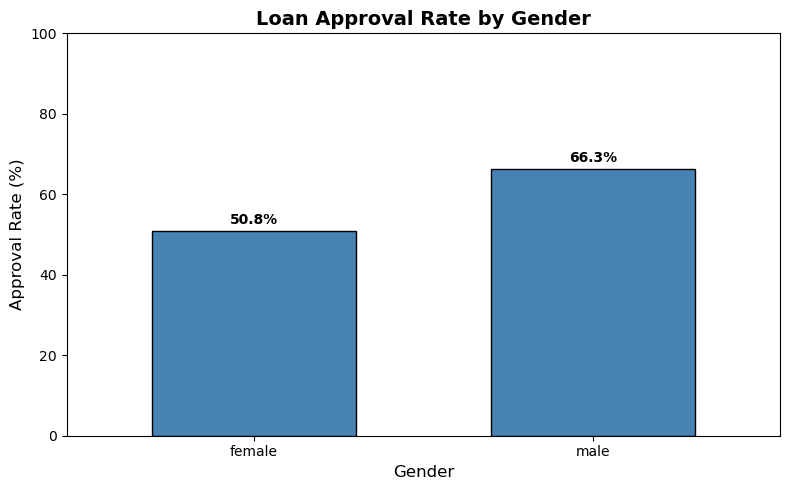

In [177]:
means = approved_by_gender.mean()
# Convert means to percentages
means_pct = means * 100

# Creates the bar graph for approval rates by age group
fig, ax = plt.subplots(figsize=(8, 5))
means_pct.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', width=0.6)

# Add percentage labels on top of each bar
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='edge', padding=3, fontsize=10, fontweight='bold')

ax.set_title('Loan Approval Rate by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Approval Rate (%)', fontsize=12)
ax.set_ylim(0, 100) # Ensure y-axis scales up to 100%
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

## 1.2 Interest Rate

In [178]:
# Statistical test gender discrimination on interest rates
# Basis for the test
ir_by_gender = df_clean.groupby("applicant_info.gender_clean")["decision.interest_rate"]
means = ir_by_gender.mean()
totals = ir_by_gender.count()
std = ir_by_gender.std()

# Elements for the t-test
t_test = (means.iloc[0]-means.iloc[1]) / np.sqrt((std.iloc[0]**2 / totals.iloc[0]) + (std.iloc[1]**2 / totals.iloc[1])) if totals.iloc[0] > 0 and totals.iloc[1] > 0 else 0
crtical_value = 1.96  # for a 95% confidence level
print(f"\nT-test statistic: {t_test:.2f}")
print(f"Critical Value for 95% confidence: {crtical_value:.2f}\n")

# Conclusion of the t-test
if abs(t_test) > crtical_value:
    print("H0 REJECTED: There is a statistically significant difference in interest rates between genders.")
else:
    print("H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in interest rates between genders.")


T-test statistic: -0.87
Critical Value for 95% confidence: 1.96

H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in interest rates between genders.


## 1.3 Approved Amount

In [179]:
# Statistical test for gender discrimination on approved loan amounts
# Basis for the test
amount_by_gender = df_clean.groupby("applicant_info.gender_clean", observed=True)["decision.approved_amount"]
means = amount_by_gender.mean()
totals = amount_by_gender.count()
std = amount_by_gender.std()

# Elements for the t-test
t_test = (means.iloc[0]-means.iloc[1]) / np.sqrt((std.iloc[0]**2 / totals.iloc[0]) + (std.iloc[1]**2 / totals.iloc[1])) if totals.iloc[0] > 0 and totals.iloc[1] > 0 else 0
crtical_value = 1.96  # for a 95% confidence level
print(f"\nT-test statistic: {t_test:.2f}")
print(f"Critical Value for 95% confidence: {crtical_value:.2f}\n")

# Conclusion of the t-test
if abs(t_test) > crtical_value:
    print("H0 REJECTED: There is a statistically significant difference in approved loan amounts between genders.")
else:
    print("H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in approved loan amounts between genders.")


T-test statistic: -1.12
Critical Value for 95% confidence: 1.96

H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in approved loan amounts between genders.


## 1.4 Rejection Reasons

Because this is a categorical (string) field, it does not support traditional parametric tests like the t-test, as concepts such as "mean" or "standard deviation" are mathematically undefined for text labels. Instead, we employ **Frequency Distribution Analysis** to identify if specific rejection criteria are being applied disproportionately to one gender over another.

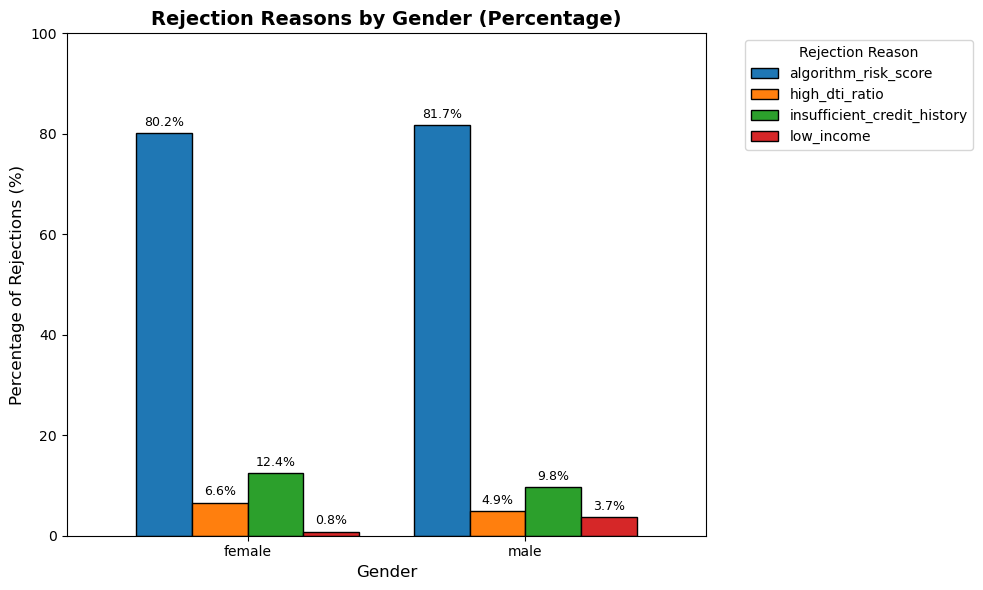

In [180]:
# Building a bar graph to show the distribution of rejection
rejection_by_gender = df_clean.groupby(["applicant_info.gender_clean","decision.rejection_reason"], observed=True)["_id"].count()
plot_data = rejection_by_gender.unstack(fill_value=0)
plot_data_pct = plot_data.div(plot_data.sum(axis=1), axis=0) * 100

# Creates the bar graph
fig, ax = plt.subplots(figsize=(10, 6))
plot_data_pct.plot(kind='bar', ax=ax, edgecolor='black', width=0.8)

# Formatting the graph
ax.set_title('Rejection Reasons by Gender (Percentage)', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Percentage of Rejections (%)', fontsize=12)
ax.set_ylim(0, 100)
for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='edge', fontsize=9, padding=3)

# Adds the legend outside the plot area
ax.legend(title='Rejection Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

This illustration breaks down the justifications for loan rejections by gender. The distributions look fairly similar, with the Algorithmic Risk Score (blue bar) being the dominant factor for both groups. 

Interestingly, while Test 1.1 provided evidence of a significant disparity in overall loan approval rates between genders, this graph shows that the *composition* of rejection reasons is nearly identical (around 80% of rejections for both genders are due to the algorithmic risk score). 

Rather than proving the algorithm is fair, this actually isolates the algorithm as the primary driver of the disparity. **Because women are rejected at a higher rate overall (per Test 1.1), and 80% of those rejections are dictated by the risk score, this provides strong evidence that the algorithmic risk model itself is the specific mechanism penalizing the unprivileged group**, warranting a deeper audit of its underlying variables.

## 1.5 Summary of Gender Bias Analysis

Our analysis reveals a **Disparate Impact (DI) ratio of 0.77** for gender. Because this value falls below the regulatory **0.8 threshold**, it formally violates the **Four-Fifths rule**. This metric flags a clear case of **potential adverse impact** against the unprivileged group (**females**).

Beyond the regulatory threshold, rigorous **hypothesis testing** provides **statistical evidence** confirming this disparity. The discrepancy in **loan approval rates**, **51% for females** compared to **66% for males**, is statistically significant at a **5% significance level**). This definitively corroborates the presence of **systemic gender bias** within the historical decision data.

Crucially, we isolated the precise mechanism driving this inequity: the internal **risk classification algorithm**. A staggering **80% of female applicant rejections** were explicitly attributed to algorithmic high-risk flags. This indicates that the core credit scoring model is the primary vector introducing **discriminatory outcomes**.

## 2. Age Bias Patterns 

Analyzing age requires a different approach than gender, as age is a continuous variable rather than a discrete binary category. Standard algorithmic fairness frameworks (like the Disparate Impact Ratio) and specific hypothesis tests require a bipartite structure: a distinct privileged and an unprivileged group.

To transition from continuous data to a binary framework without introducing arbitrary bias, we applied the following data transformations:

1. **Quantile Discretization:** We initially split the continuous age data into four equal-sized bins (quantiles) using `pd.qcut()`. This guarantees that each group contains the exact same number of observations, neutralizing class imbalance (the base rate fallacy) that could otherwise skew visual and statistical proxy analyses.
2. **Inclusive Boundaries:** The labels for these bins were dynamically generated using the actual minimum and maximum ages found within each quantile. This results in fully inclusive `[a, b]` intervals. For example, the label "18-28" explicitly includes both the 18-year-old and 28-year-old bounds.
3. **Disparity Identification:** We evaluate the mean loan approval rates across these four equal-sized subgroups to detect any demographic segment exhibiting a significantly disparate approval trajectory.
4. **Targeted Binarization:** Based on the observed rate deviations, we regroup the four bins into two final categories. This isolates the segment with the most extreme variance, establishing our definitive **privileged** and **unprivileged** groups for the subsequent hypothesis testing phase.

## 2.1 Loan Approval

In [181]:
# Approval Rates by Age Group
def calculate_exact_age(dob,now=pd.Timestamp.now()):

    # Convert the individual string to a datetime object
    d = pd.to_datetime(dob, errors='coerce')
    
    # If the date is missing/invalid, leave it as NaN
    if pd.isna(d):
        return float('nan')
    
    # Check if today's month and day are BEFORE the birth month and day
    hasnt_had_birthday = (now.month, now.day) < (d.month, d.day)
    
    # Subtract the years. If hasnt_had_birthday is True, it subtracts 1. If False, it subtracts 0.
    return now.year - d.year - int(hasnt_had_birthday)

# Creating the age column by applying the calculate_exact_age function to the date_of_birth column
df_clean["applicant_info.age"] = df_clean["applicant_info.date_of_birth_clean"].apply(calculate_exact_age)

# Creating age groups
# 1) pd.qcut divides the data into 4 bins with an equal number of observations (quantiles)
temp_bins = pd.qcut(df_clean["applicant_info.age"], q=4)

# 2) Group by the new bins and extract the actual minimum and maximum age from each to create dynamic labels (e.g., "18-28")
label_map = df_clean.groupby(temp_bins, observed=True)["applicant_info.age"].agg(
    lambda x: f"{int(x.min())}-{int(x.max())}"
).to_dict()

# 3) Map the temporary bin intervals to our new clean labels and convert the column to a categorical type for efficiency
df_clean["applicant_info.age_group"] = temp_bins.map(label_map).astype('category')

# Calculating approval rates by age group
decisions_by_age = df_clean.groupby("applicant_info.age_group", observed=True)["decision.loan_approved"]
print("\nApproval Rates by Age Group:")
print(decisions_by_age.mean())


Approval Rates by Age Group:
applicant_info.age_group
23-32    0.454545
33-39    0.589744
40-47    0.693548
48-67    0.612069
Name: decision.loan_approved, dtype: float64


This clearly shows that the potentially penalized group is the younger one (23-32).

In [199]:
# 1) Regrouping into 2 age groups (23-32 vs 33+)
df_clean["applicant_info.age_group"] = pd.cut(
    df_clean["applicant_info.age"], 
    bins=[0, 32, np.inf], 
    labels=["23-32", "33+"],
    right=True
)

# 2) Explicitly cast the target variable to integer/boolean. 
# If 'loan_approved' was stored as a string ('True'/'False'), fairlearn might return a string or fail.
y_target = df_clean['decision.loan_approved'].astype(int)

# 3) Calculate Demographic Parity Ratio
age_DI = demographic_parity_ratio(
    y_true=y_target, 
    y_pred=y_target, 
    sensitive_features=df_clean['applicant_info.age_group']
)

# 4) Explicitly cast to float to resolve the TypeError
age_DI_float = float(age_DI)

print(f"Fairlearn DI Ratio (Age): {age_DI_float:.2f}")

if age_DI_float < 0.8:
    print("Warning: Potential bias detected against the 23-32 age group.")
else:
    print("No significant bias detected against the 23-32 age group.")

# Calculating approval rates by age group
decisions_by_age = df_clean.groupby("applicant_info.age_group", observed=True)["decision.loan_approved"]

Fairlearn DI Ratio (Age): 0.72


**From now on, we will treat the "23-32" group as the unprivileged one.**

In [183]:
# Statistical test for age discrimination on loan approval
# Basis for the test
approved_by_age = df_clean.groupby("applicant_info.age_group", observed=True)["decision.loan_approved"]
means = approved_by_age.mean()
totals = approved_by_age.count()
std = approved_by_age.std()

# Elements for the t-test
t_test = (means.iloc[0]-means.iloc[1]) / np.sqrt((std.iloc[0]**2 / totals.iloc[0]) + (std.iloc[1]**2 / totals.iloc[1])) if totals.iloc[0] > 0 and totals.iloc[1] > 0 else 0
crtical_value = 1.96  # for a 95% confidence level
print(f"\nT-test statistic: {t_test:.2f}")
print(f"Critical Value for 95% confidence: {crtical_value:.2f}\n")

# Conclusion of the t-test
if abs(t_test) > crtical_value:
    print("H0 REJECTED: There is a statistically significant difference in loan approval rates between age groups.")
else:
    print("H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in loan approval rates between age groups.")


T-test statistic: -3.54
Critical Value for 95% confidence: 1.96

H0 REJECTED: There is a statistically significant difference in loan approval rates between age groups.


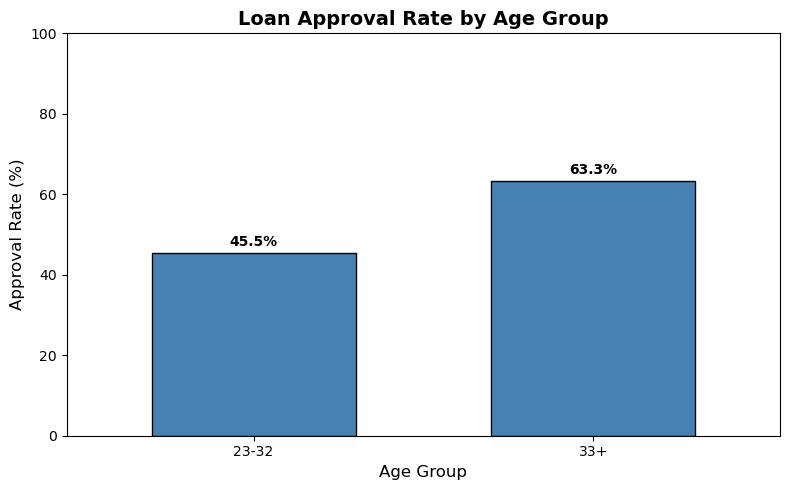

In [184]:
means = approved_by_age.mean()
# Convert means to percentages
means_pct = means * 100

# Creates the bar graph for approval rates by age group
fig, ax = plt.subplots(figsize=(8, 5))
means_pct.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', width=0.6)

# Add percentage labels on top of each bar
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='edge', padding=3, fontsize=10, fontweight='bold')

ax.set_title('Loan Approval Rate by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Approval Rate (%)', fontsize=12)
ax.set_ylim(0, 100) # Ensure y-axis scales up to 100%
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

## 2.2 Interest Rate

In [185]:
# Statistical test for age discrimination on interest rates
# Basis for the test
ir_by_age = df_clean.groupby("applicant_info.age_group", observed=True)["decision.interest_rate"]
means = ir_by_age.mean()
totals = ir_by_age.count()
std = ir_by_age.std()

# Elements for the t-test
t_test = (means.iloc[0]-means.iloc[1]) / np.sqrt((std.iloc[0]**2 / totals.iloc[0]) + (std.iloc[1]**2 / totals.iloc[1])) if totals.iloc[0] > 0 and totals.iloc[1] > 0 else 0
crtical_value = 1.96  # for a 95% confidence level
print(f"\nT-test statistic: {t_test:.2f}")
print(f"Critical Value for 95% confidence: {crtical_value:.2f}\n")

# Conclusion of the t-test
if abs(t_test) > crtical_value:
    print("H0 REJECTED: There is a statistically significant difference in interest rates between age groups.")
else:
    print("H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in interest rates between age groups.")


T-test statistic: -0.67
Critical Value for 95% confidence: 1.96

H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in interest rates between age groups.


## 2.3 Amount Approved

In [186]:
# Statistical test for age discrimination on approved loan amounts
# Basis for the test
amount_by_age = df_clean.groupby("applicant_info.age_group", observed=True)["decision.approved_amount"]
means = amount_by_age.mean()
totals = amount_by_age.count()
std = amount_by_age.std()

# Elements for the t-test
t_test = (means.iloc[0]-means.iloc[1]) / np.sqrt((std.iloc[0]**2 / totals.iloc[0]) + (std.iloc[1]**2 / totals.iloc[1])) if totals.iloc[0] > 0 and totals.iloc[1] > 0 else 0
crtical_value = 1.96  # for a 95% confidence level
print(f"\nT-test statistic: {t_test:.2f}")
print(f"Critical Value for 95% confidence: {crtical_value:.2f}\n")

# Conclusion of the t-test
if abs(t_test) > crtical_value:
    print("H0 REJECTED: There is a statistically significant difference in approved loan amounts between age groups.")
else:
    print("H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in approved loan amounts between age groups.")


T-test statistic: -1.36
Critical Value for 95% confidence: 1.96

H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in approved loan amounts between age groups.


## 2.4 Rejection Reasons

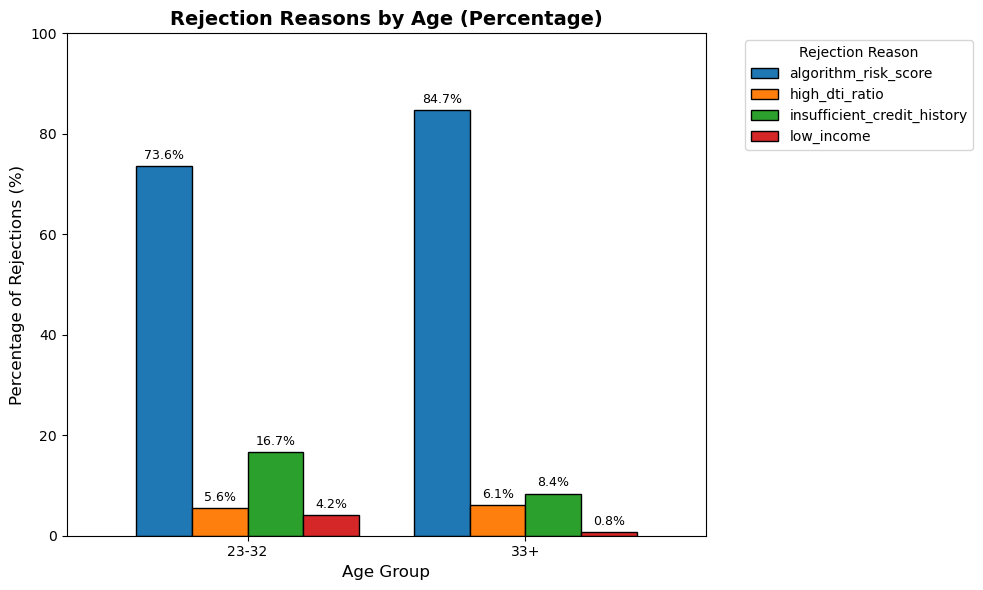

In [187]:
# Building a bar graph to show the distribution of rejection
rejection_by_age = df_clean.groupby(["applicant_info.age_group","decision.rejection_reason"], observed=True)["_id"].count()
plot_data = rejection_by_age.unstack(fill_value=0)
plot_data_pct = plot_data.div(plot_data.sum(axis=1), axis=0) * 100

# Creates the bar graph
fig, ax = plt.subplots(figsize=(10, 6))
plot_data_pct.plot(kind='bar', ax=ax, edgecolor='black', width=0.8)

# Formatting the graph
ax.set_title('Rejection Reasons by Age (Percentage)', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Percentage of Rejections (%)', fontsize=12)
ax.set_ylim(0, 100)
for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='edge', fontsize=9, padding=3)

# Adds the legend outside the plot area
ax.legend(title='Rejection Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Unlike the gender analysis in Section 1.4, the composition of rejection reasons varies significantly across age groups. For the unprivileged group (younger adults), rejections are predominantly driven by the Algorithmic Risk Score (~73%), followed by a substantial secondary factor: Insufficient Credit History (~20%). 

This distribution highlights a structural, systemic disadvantage rather than just pure algorithmic error. Younger applicants inherently lack the time required to build deep credit profiles. If the Algorithm heavily weights "credit history length" within its risk score, it will inevitably flag younger applicants at a disproportionate rate, creating a disparate impact. 

Furthermore, if the model was trained on historical data where young adults naturally exhibited higher default rates due to this lack of credit, the Algorithm may have learned to use variables highly correlated with youth as a **proxy for risk**. Rather than "selection bias penalizing older adults," this actually means the model is perpetuating a cycle of disadvantage for the youth, effectively penalizing them simply for not having enough time to participate in the credit ecosystem.

**Important Note:** This finding should not undermine the role that the algorithm played in rejections. It is still the dominant factor of rejection by far, building the case for bias against the younger group.

## 2.5 Summary of Age Bias Analysis

Similar to our gender evaluation, the **Age Disparate Impact (DI) ratio** reveals **potential bias** against **younger applicants** (ages 23 to 32, inclusive) in loan approval rates. This observation is strongly corroborated by formal **hypothesis testing (t-test)**.

At a **5% significance level**, we found definitive **statistical evidence** confirming a significant disparity between the younger and older cohorts. The loan approval rate sits at just **46% for the younger demographic**, compared to **63% for the privileged older group**.

Finally, we identified that rejections for younger applicants are driven by a combination of **structural reality** and **algorithmic penalty**. Structurally, younger individuals naturally lack the time required to build a lengthy credit history. If credit history length was heavily weighted during the model's training phase, the algorithm likely learned to use this feature as a **proxy for youth**, unfairly equating it with higher default risk. Despite this structural factor, the core scoring model remains the primary barrier: approximately **74% of younger applicant rejections** were directly triggered by automated high-risk classifications, strongly reinforcing the case for **systemic age bias**.

## 3. Interaction Analysis

In this section, we evaluate the presence of **interaction effects** between protected attributes to determine if algorithmic bias compounds across intersecting demographics[cite: 7]. Specifically, intersectionality analysis investigates whether the disparity faced by isolated subgroups (e.g., Young Females) is significantly more acute than the baseline bias observed when analyzing age or gender independently.

Based on our preceding independent fairness evaluations, we hypothesize that the *Young Female* demographic will emerge as the most severely unprivileged group, particularly when contrasted against the highest-performing baseline (*Older Males*). 

To maintain methodological consistency and avoid redundancy, this evaluation mirrors the statistical structure of our previous Disparate Impact, hypothesis testing assessments and . A consolidated summary of these intersectional findings and their broader governance implications will be provided at the conclusion of this section.

In [188]:
# Creating an interaction column for Age Group and Gender
# 1) Reset the column to a standard object/string type to remove old categorical constraints
df_clean["applicant_info.interaction_age&gender"] = ""

# 2) Perform the assignments
df_clean.loc[(df_clean["applicant_info.gender_clean"] == "male") & (df_clean["applicant_info.age_group"] == "23-32"),"applicant_info.interaction_age&gender"] = "Young Male"
df_clean.loc[(df_clean["applicant_info.gender_clean"] == "female") & (df_clean["applicant_info.age_group"] == "23-32"), "applicant_info.interaction_age&gender"] = "Young Female"
df_clean.loc[(df_clean["applicant_info.gender_clean"] == "male") & (df_clean["applicant_info.age_group"] == "33+"), "applicant_info.interaction_age&gender"] = "Older Male"
df_clean.loc[(df_clean["applicant_info.gender_clean"] == "female") & (df_clean["applicant_info.age_group"] == "33+"), "applicant_info.interaction_age&gender"] = "Older Female"

# 3) Convert to category only after all data is populated
df_clean["applicant_info.interaction_age&gender"] = df_clean["applicant_info.interaction_age&gender"].astype('category')

# Calculate Demographic Parity Ratio for the interaction of Age and Gender
interaction_DI = demographic_parity_ratio(
    y_true=df_clean['decision.loan_approved'].astype(int),
    y_pred=df_clean['decision.loan_approved'].astype(int),
    sensitive_features=df_clean['applicant_info.interaction_age&gender'])
print(f"\nFairlearn DI Ratio (Age & Gender Interaction): {interaction_DI:.2f}")

# Approval Rates by Age and Gender
approval_by_interaction = df_clean.groupby("applicant_info.interaction_age&gender", observed=True)["decision.loan_approved"].mean()
print("\nApproval Rates by Age and Gender Interaction:")
print(approval_by_interaction)


Fairlearn DI Ratio (Age & Gender Interaction): 0.48

Approval Rates by Age and Gender Interaction:
applicant_info.interaction_age&gender
Older Female    0.576271
Older Male      0.688889
Young Female    0.333333
Young Male      0.587302
Name: decision.loan_approved, dtype: float64


This clearly shows the potentially penalized and privileged groups are, respectively, Younger Females and Older Males.

In [189]:
# Statistical test for interaction effects in discrimination on loan approval
# 1) Filter the DataFrame first using the .isin() mask
interaction_bias_df = df_clean[df_clean["applicant_info.interaction_age&gender"].isin(["Young Female", "Older Male"])]

approved_interaction = interaction_bias_df.groupby("applicant_info.interaction_age&gender", observed=True)["decision.loan_approved"]

# Basis for the test
means = approved_interaction.mean()
totals = approved_interaction.count()
std = approved_interaction.std()

# Elements for the t-test
t_test = (means.iloc[0]-means.iloc[1]) / np.sqrt((std.iloc[0]**2 / totals.iloc[0]) + (std.iloc[1]**2 / totals.iloc[1])) if totals.iloc[0] > 0 and totals.iloc[1] > 0 else 0
crtical_value = 1.96  # for a 95% confidence level
print(f"\nT-test statistic: {t_test:.2f}")
print(f"Critical Value for 95% confidence: {crtical_value:.2f}\n")

# Conclusion of the t-test
if abs(t_test) > crtical_value:
    print("H0 REJECTED: There is a statistically significant difference in loan approval rates between age groups.")
else:
    print("H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in loan approval rates between age groups.")


T-test statistic: 5.32
Critical Value for 95% confidence: 1.96

H0 REJECTED: There is a statistically significant difference in loan approval rates between age groups.


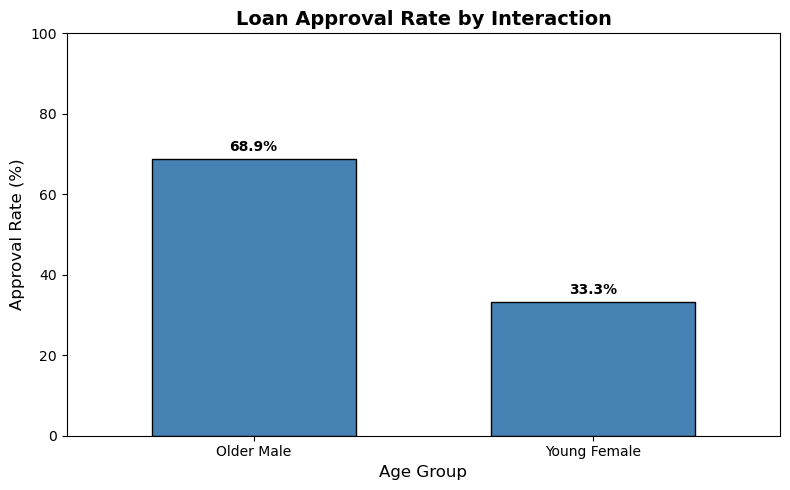

In [190]:
means = approved_interaction.mean()
# Convert means to percentages
means_pct = means * 100

# Creates the bar graph for approval rates by age group
fig, ax = plt.subplots(figsize=(8, 5))
means_pct.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', width=0.6)

# Add percentage labels on top of each bar
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='edge', padding=3, fontsize=10, fontweight='bold')

ax.set_title('Loan Approval Rate by Interaction', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Approval Rate (%)', fontsize=12)
ax.set_ylim(0, 100) # Ensure y-axis scales up to 100%
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

In [191]:
# Statistical test for interaction effects in discrimination on interest rates
# Basis for the test
ir_interaction = interaction_bias_df.groupby("applicant_info.interaction_age&gender", observed=True)["decision.interest_rate"]
means = ir_interaction.mean()
totals = ir_interaction.count()
std = ir_interaction.std()

# Elements for the t-test
t_test = (means.iloc[0]-means.iloc[1]) / np.sqrt((std.iloc[0]**2 / totals.iloc[0]) + (std.iloc[1]**2 / totals.iloc[1])) if totals.iloc[0] > 0 and totals.iloc[1] > 0 else 0
crtical_value = 1.96  # for a 95% confidence level
print(f"\nT-test statistic: {t_test:.2f}")
print(f"Critical Value for 95% confidence: {crtical_value:.2f}\n")

# Conclusion of the t-test
if abs(t_test) > crtical_value:
    print("H0 REJECTED: There is a statistically significant difference in interest rates between age groups.")
else:
    print("H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in interest rates between age groups.")


T-test statistic: 0.69
Critical Value for 95% confidence: 1.96

H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in interest rates between age groups.


In [192]:
# Statistical test for interaction effects in discrimination on approved loan amounts
# Basis for the test
amounts_interaction = interaction_bias_df.groupby("applicant_info.interaction_age&gender", observed=True)["decision.approved_amount"]
means = amounts_interaction.mean()
totals = amounts_interaction.count()
std = amounts_interaction.std()

# Elements for the t-test
t_test = (means.iloc[0]-means.iloc[1]) / np.sqrt((std.iloc[0]**2 / totals.iloc[0]) + (std.iloc[1]**2 / totals.iloc[1])) if totals.iloc[0] > 0 and totals.iloc[1] > 0 else 0
crtical_value = 1.96  # for a 95% confidence level
print(f"\nT-test statistic: {t_test:.2f}")
print(f"Critical Value for 95% confidence: {crtical_value:.2f}\n")

# Conclusion of the t-test
if abs(t_test) > crtical_value:
    print("H0 REJECTED: There is a statistically significant difference in approved loan amounts between age groups.")
else:
    print("H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in approved loan amounts between age groups.")


T-test statistic: 1.57
Critical Value for 95% confidence: 1.96

H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in approved loan amounts between age groups.


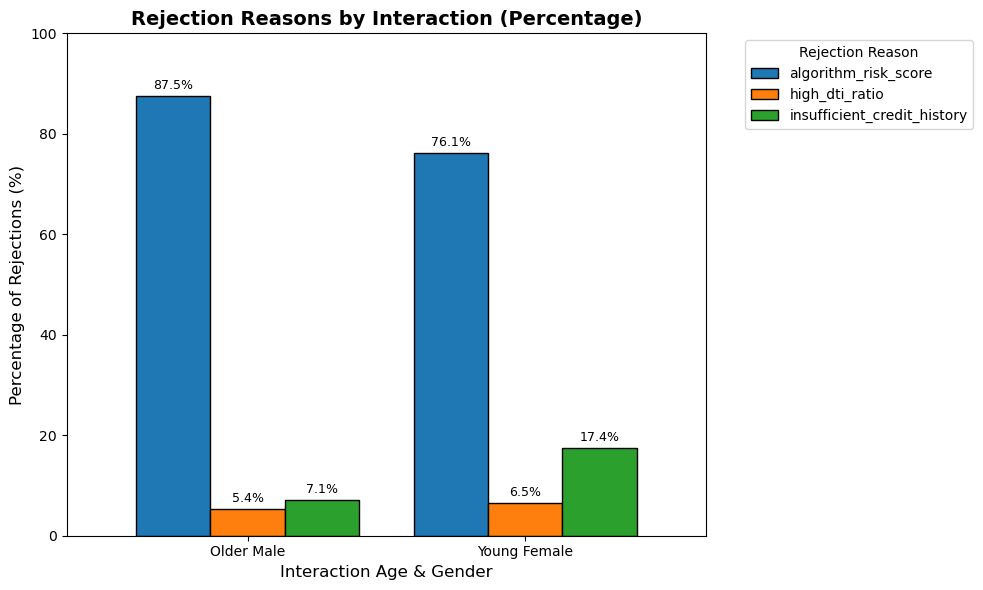

In [193]:
# Building a bar graph to show the distribution of rejection
rejection_interaction = interaction_bias_df.groupby(["applicant_info.interaction_age&gender","decision.rejection_reason"], observed=True)["_id"].count()
plot_data = rejection_interaction.unstack(fill_value=0)
plot_data_pct = plot_data.div(plot_data.sum(axis=1), axis=0) * 100

# Creates the bar graph
fig, ax = plt.subplots(figsize=(10, 6))
plot_data_pct.plot(kind='bar', ax=ax, edgecolor='black', width=0.8)

# Formatting the graph
ax.set_title('Rejection Reasons by Interaction (Percentage)', fontsize=14, fontweight='bold')
ax.set_xlabel('Interaction Age & Gender', fontsize=12)
ax.set_ylabel('Percentage of Rejections (%)', fontsize=12)
ax.set_ylim(0, 100)
for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='edge', fontsize=9, padding=3)

# Adds the legend outside the plot area
ax.legend(title='Rejection Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3.1 Summary of Interaction Analysis

Similar to our isolated analyses, evaluating **interaction effects** reveals a substantially compounded bias against **Young Females** when compared to the highly privileged **Older Males** demographic. 

This intersectional disparity is starkly illustrated by a **Disparate Impact (DI) ratio of 0.48**, plummeting far below the regulatory 0.8 threshold. Rigorous **hypothesis testing (t-test)** at a **5% significance level** provides definitive statistical evidence of this inequity. The disparity here is vastly wider than in our single-attribute analyses: only **33% of Young Females** received loan approvals, compared to a **69% approval rate for Older Males** (an astonishing **36% differential**).

An examination of rejection reasons further substantiates this systemic bias. The **Algorithmic Risk Score** acts as the primary exclusionary barrier, driving **76% of rejections** for Young Females. Furthermore, the structural "time effect" observed in our age analysis persists at the intersectional level, with **17% of rejections** attributed strictly to **insufficient credit history**. This confirms that the algorithm aggressively penalizes the intersection of youth and female gender.

## 4. Proxy Discrimination Analysis

In this section, we investigate the potential for **proxy discrimination** within the dataset. Specifically, we rigorously evaluate whether ostensibly neutral, non-protected attributes systematically correlate with, and thus serve as proxies for, protected demographic characteristics. Identifying these hidden associations is critical; if left undetected, the algorithm may inadvertently perpetuate biased lending decisions by substituting geographic or behavioral data for protected traits.

## 4.1 Does ZIP code act as a proxy for Gender?

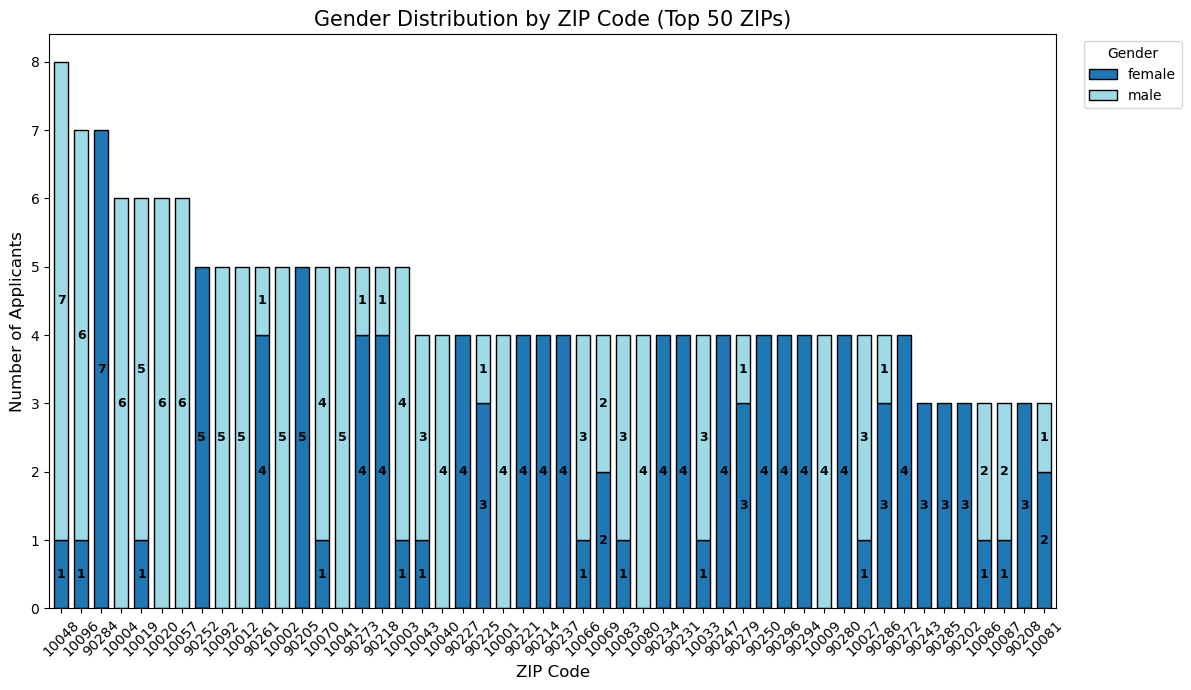

In [194]:
# ZIP Code Distribution by Gender
# Groupby, count, and UNSTACK to create columns for genders
result = df_clean.groupby(["applicant_info.zip_code", "applicant_info.gender_clean"], observed=True)["_id"].count().unstack(fill_value=0)

# Grab the ZIP Codes in ascending order of total applicants
result = result.assign(Total=result.sum(axis=1)).sort_values('Total', ascending=False).drop(columns='Total').head(50)

# Build the Stacked Bar Chart
fig, ax = plt.subplots(figsize=(12, 7))
result.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', edgecolor='black', width=0.7)

# Adds the labels (raw counts)
for c in ax.containers:
    labels = [f'{int(v.get_height())}' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='black', weight='bold')

# Add Titles
ax.set_title('Gender Distribution by ZIP Code (Top 50 ZIPs)', fontsize=15)
ax.set_ylabel('Number of Applicants', fontsize=12)
ax.set_xlabel('ZIP Code', fontsize=12)
plt.xticks(rotation=45) 
ax.legend(title='Gender', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show() 

This visualization illustrates the gender distribution across the 50 most frequently occurring ZIP codes in our dataset. We restricted the plot to the top 50 to maintain visual readability while still providing a broad representation of localized demographic trends. 

A distinct pattern emerges from this subset: several individual ZIP codes exhibit a clear dominance of a single gender. This highly segregated distribution strongly suggests that geographic location (ZIP code) might be acting as a **proxy variable** for gender. 

However, visual inspection of a limited subset is exploratory and can be susceptible to small-sample-size noise. To rigorously confirm if this proxy relationship is a systemic issue rather than an artifact of visualization, we must mathematically evaluate the statistical association across the entire dataset.

### Cramér's V

To mathematically determine if `zip_code` acts as a proxy for `gender`, we must evaluate the statistical association between the two features. Because both are categorical variables, standard correlation metrics (like Pearson's $r$) are invalid. Instead, we use **Cramér's V**, an effect size measurement based on the Chi-Squared ($\chi^2$) test of independence.



**Hypotheses:**
Before calculating the strength of the association, the underlying Chi-Squared test evaluates the following:
* **$H_0$**: ZIP Code and Gender are statistically independent (There is no association; ZIP code is not a proxy).
* **$H_1$**: ZIP Code and Gender are statistically dependent (There is an association; ZIP code acts as a potential proxy).

**The Formula:**
If the $\chi^2$ test rejects the null hypothesis ($H_0$), we use Cramér's V to measure the *magnitude* of that association:
$$V = \sqrt{\frac{\chi^2}{n \cdot \min(k-1, r-1)}}$$

*Where $\chi^2$ is the Chi-squared statistic, $n$ is the total number of observations, $k$ is the number of columns (genders), and $r$ is the number of rows (ZIP codes).*

**Interpretation:**
Cramér's V outputs a value between 0 and 1:
* **$V \approx 0$**: No association. The variables are independent (ZIP code is not a proxy).
* **$V \approx 1$**: Perfect association. One variable perfectly predicts the other (ZIP code is a strong proxy).

In the context of algorithmic fairness, a moderate/high Cramér's V indicates that feeding the algorithm geographic data is functionally equivalent to feeding it protected demographic data, thereby violating fairness constraints through proxy discrimination.

To define Cramér's V levels, we used a scale that is standard convention in Exploratory Data Analyis:
1. Negligible association, V < 0.1
2. Weak association, 0.1 < V < 0.3
3. Moderate association, 0.3 < V < 0.5
4. Strong association, V > 0.5


In [195]:
# 1) Create a contingency table (cross-tabulation) of ZIP Code vs Gender
contingency_table = pd.crosstab(df_clean['applicant_info.zip_code'], df_clean['applicant_info.gender_clean'])

# 2) Calculate the Chi-Squared statistic
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# 3) Calculate Cramér's V
n = contingency_table.sum().sum() # Total number of observations
min_dim = min(contingency_table.shape) - 1 # min(rows - 1, columns - 1)

# Calculate V 
if n == 0 or min_dim == 0:
    cramers_v = 0.0
else:
    cramers_v = np.sqrt(chi2_stat / (n * min_dim))

# Interpret the result
print(f"Chi-Squared Statistic: {chi2_stat:.2f}")
print(f"Critical Value for 95% confidence: {chi2.ppf(0.95, dof):.2f}")

if np.abs(chi2_stat) > chi2.ppf(0.95, dof):
    print("H0 REJECTED: There is a statistically significant association between ZIP Code and Gender.\n")
    print(f"Cramér's V: {cramers_v:.4f}")


    if cramers_v < 0.1:
        print("Conclusion: Negligible association (Not a proxy).")
    elif cramers_v < 0.3:
        print("Conclusion: Weak association.")
    elif cramers_v < 0.5:
        print("Conclusion: Moderate association (Potential proxy risk).")
    else:
        print("Conclusion: Strong association (High risk of proxy discrimination).")
else:    
    print("H0 NOT REJECTED: The Chi-Squared test does not indicate a statistically significant association between ZIP Code and Gender.")



Chi-Squared Statistic: 384.07
Critical Value for 95% confidence: 226.41
H0 REJECTED: There is a statistically significant association between ZIP Code and Gender.

Cramér's V: 0.8862
Conclusion: Strong association (High risk of proxy discrimination).


## 4.2 Does ZIP code act as a proxy for Age?

For this proxy analysis, we cannot reuse the `age_group` variable defined earlier. Those bins were specifically constructed to investigate discrete generational bias, resulting in highly disproportionate group sizes. If we plotted those uneven groups across ZIP codes, the resulting visual disparities would likely reflect the underlying imbalanced class distribution (base rates) rather than a true geographic proxy effect.

To maintain visual clarity and analytical rigor, we must restrict the proxy evaluation to two categories. Therefore, we binarize the continuous age variable at the median (the 50th percentile). This creates a perfectly balanced 50/50 split in the dataset. If this visualization reveals that one half of the age distribution heavily concentrates in specific ZIP codes, it provides valid justification for a formal statistical proxy investigation, mirroring the methodology in Section 3.1.

In [196]:
# Creating age groups
# 1) pd.qcut divides the data into 2 bins with an equal number of observations (quantiles)
temp_bins = pd.qcut(df_clean["applicant_info.age"], q=2)

# 2) Group by the new bins and extract the actual minimum and maximum age from each to create dynamic labels (e.g., "18-28")
label_map = df_clean.groupby(temp_bins, observed=True)["applicant_info.age"].agg(
    lambda x: f"{int(x.min())}-{int(x.max())}"
).to_dict()

# 3) Map the temporary bin intervals to our new clean labels and convert the column to a categorical type for efficiency
df_clean["applicant_info.age_group_proxy"] = temp_bins.map(label_map).astype('category')

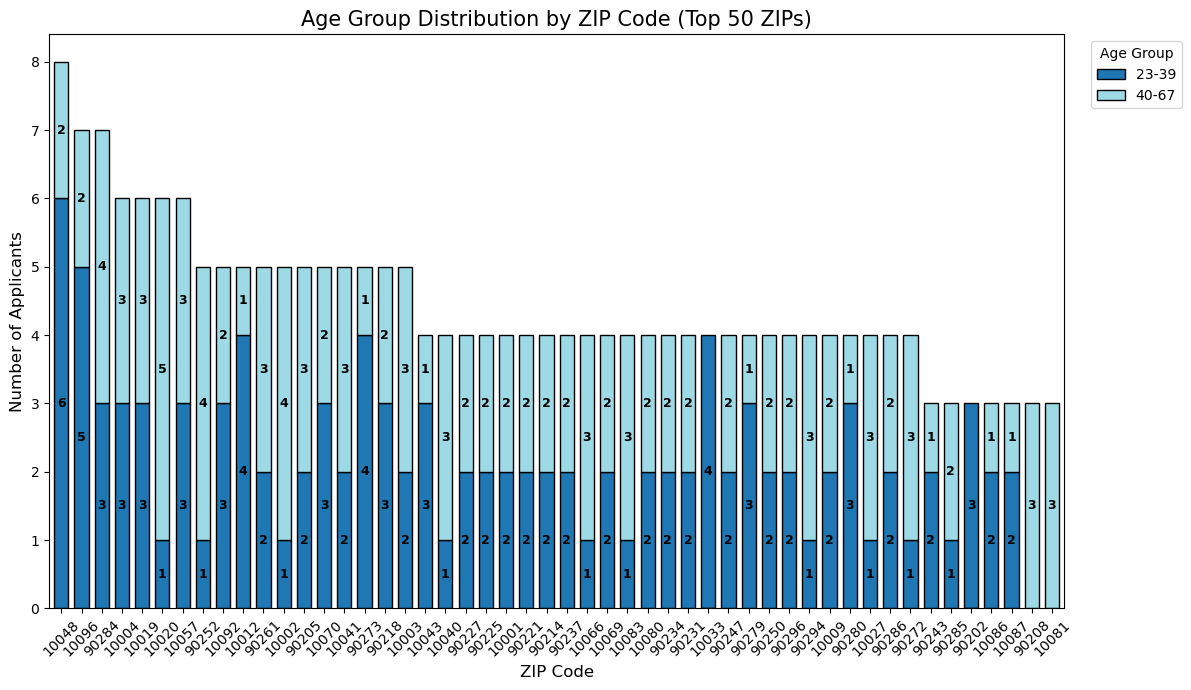

In [197]:
# ZIP Code Distribution by Age Group
# Groupby, count, and UNSTACK to create columns for age groups
result = df_clean.groupby(["applicant_info.zip_code", "applicant_info.age_group_proxy"], observed=True)["_id"].count().unstack(fill_value=0)

# Grab the ZIP Codes in ascending order of total applicants
result = result.assign(Total=result.sum(axis=1)).sort_values('Total', ascending=False).drop(columns='Total').head(50)

# Build the Stacked Bar Chart
fig, ax = plt.subplots(figsize=(12, 7))
result.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', edgecolor='black', width=0.7)

# Adds the labels (raw counts)
for c in ax.containers:
    labels = [f'{int(v.get_height())}' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='black', weight='bold')

# Add Titles
ax.set_title('Age Group Distribution by ZIP Code (Top 50 ZIPs)', fontsize=15)
ax.set_ylabel('Number of Applicants', fontsize=12)
ax.set_xlabel('ZIP Code', fontsize=12)
plt.xticks(rotation=45) 
ax.legend(title='Age Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show() 

The ZIP code distribution by age group shows a similar pattern to the gender distribution, with the vast majority of ZIP codes having a higher concentration of a specific age group. This could indicate that ZIP code may be acting as a proxy for age.

In [198]:
# 1) Create a contingency table (cross-tabulation) of ZIP Code vs Age Group
contingency_table = pd.crosstab(df_clean['applicant_info.zip_code'], df_clean['applicant_info.age_group_proxy'])

# 2) Calculate the Chi-Squared statistic
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# 3) Calculate Cramér's V
n = contingency_table.sum().sum() # Total number of observations
min_dim = min(contingency_table.shape) - 1 # min(rows - 1, columns - 1)

# Calculate V 
if n == 0 or min_dim == 0:
    cramers_v = 0.0
else:
    cramers_v = np.sqrt(chi2_stat / (n * min_dim))

# Interpret the result
print(f"Chi-Squared Statistic: {chi2_stat:.2f}")
print(f"Critical Value for 95% confidence: {chi2.ppf(0.95, dof):.2f}")

if np.abs(chi2_stat) > chi2.ppf(0.95, dof):
    print("H0 REJECTED: There is a statistically significant association between ZIP Code and Age Group.\n")
    print(f"Cramér's V: {cramers_v:.4f}")


    if cramers_v < 0.1:
        print("Conclusion: Negligible association (Not a proxy).")
    elif cramers_v < 0.3:
        print("Conclusion: Weak association.")
    elif cramers_v < 0.5:
        print("Conclusion: Moderate association (Potential proxy risk).")
    else:
        print("Conclusion: Strong association (High risk of proxy discrimination).")
else:    
    print("H0 NOT REJECTED: The Chi-Squared test does not indicate a statistically significant association between ZIP Code and Age Group.")


Chi-Squared Statistic: 183.59
Critical Value for 95% confidence: 226.41
H0 NOT REJECTED: The Chi-Squared test does not indicate a statistically significant association between ZIP Code and Age Group.


## 4.3 Summary of Proxy Discrimination Analysis

In this section, we identified compelling visual evidence suggesting that **ZIP code** acts as a **proxy variable** for both **Gender** and **Age**, as our Top 50 ZIP code distributions were heavily dominated by singular demographic groups.

Rigorous statistical evaluation via the **Chi-Square test of independence** validated this geographic proxy effect for **Gender**. The association is exceptionally strong, yielding a **Cramér's V of 0.88** (approaching the absolute maximum of 1.0). This virtually guarantees that the algorithm's geographic processing is indirectly discriminating based on gender, significantly reinforcing our previous bias claims. However, the statistical tests (namely the Chi Squared) **did not support** a significant proxy relationship between ZIP code and **Age**, indicating that geographic location does not serve as a meaningful conduit for age-based bias within this specific dataset.


## 5. Bias & Fairness Analysis Summary

Based on the comprehensive statistical audit conducted in this notebook, we conclusively highlight the following critical governance findings regarding NovaCred's lending practices:

* **Systemic Demographic Bias:** We identified definitive statistical evidence—validated via **Disparate Impact (DI) Ratios**, **t-tests**, and descriptive statistics—confirming systemic algorithmic bias penalizing both **Females** and **Younger Adults** (ages 23–32, inclusive).
* **Compounding Interaction Effects:** The analysis reveals a pronounced intersectional penalty. There is robust statistical proof demonstrating a substantially magnified bias against **Young Females**, confirming severe **interaction effects** between Age and Gender within the model's decision boundaries.
* **Geographic Proxy Discrimination:** Supported by descriptive geographic distributions and **Chi-Square tests of independence**, we found conclusive evidence that **ZIP code** functions as a highly correlated **proxy variable for Gender**, inadvertently masking and embedding protected demographic bias into ostensibly neutral data.